In [2]:
import os
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

print("Working directory:", os.getcwd())


/Users/manqiyang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Working directory: /Users/manqiyang/Desktop/assetmanagement_homework


In [3]:
BASE_DIR = "/Users/manqiyang/Desktop/assetmanagement_homework/DE_AT_CH_data_annual"

monthly_path = os.path.join(BASE_DIR,"DE_AT_CH_data_monthly.csv")
annual_path  = os.path.join(BASE_DIR,"DE_AT_CH_data_annual.csv")
firms_path   = os.path.join(BASE_DIR,"DE_AT_CH_firms.csv")
ff_path      = os.path.join(BASE_DIR,"Europe_FF_Factors.csv")

monthly = pd.read_csv(monthly_path)
annual  = pd.read_csv(annual_path)
firms   = pd.read_csv(firms_path)
ff      = pd.read_csv(ff_path)

{
    "monthly_shape": monthly.shape,
    "annual_shape": annual.shape,
    "firms_shape": firms.shape,
    "ff_shape": ff.shape,
}



{'monthly_shape': (210576, 9),
 'annual_shape': (19838, 5),
 'firms_shape': (1546, 4),
 'ff_shape': (349, 6)}

In [4]:
print("=== monthly ===")
display(monthly.head())

print("=== annual ===")
display(annual.head())

print("=== firms ===")
display(firms.head())

print("=== ff factors ===")
display(ff.head())


=== monthly ===


,ISIN,mdate,RET,RET11,ME,b,h,s,ivol
0,DE000A11QW68,200606,-0.0264,0.3490,100.6032,1.7711,1.9829,2.2792,0.0243
1,DE000A11QW68,200607,-0.1719,-0.0728,83.3189,1.9704,1.3950,2.1592,0.0147
2,DE000A11QW68,200608,-0.0005,-0.2091,83.2671,2.0917,0.5516,2.4282,0.0298
3,DE000A11QW68,200609,-0.1441,-0.1636,71.2674,2.1569,1.4690,2.0897,0.0166
4,DE000A11QW68,200610,-0.4920,-0.5568,36.1973,1.7767,2.1637,2.2076,0.0674


=== annual ===


,ISIN,fyear,BEME,OP,INV
0,AT000000STR1,2007,0.5038,0.2386,0.3947
1,AT000000STR1,2008,1.5017,0.2867,0.2589
2,AT000000STR1,2009,1.2163,0.3091,-0.0153
3,AT000000STR1,2010,1.2520,0.2903,0.0726
4,AT000000STR1,2011,1.1162,0.3335,0.0044


=== firms ===


,ISIN,name,country,dscode
0,AT000000STR1,STRABAG SE,AT,51200L
1,AT00000AMAG3,AMAG AUSTRIA METALL AG,AT,75660K
2,AT00000ATEC9,A-TEC INDUSTRIES AG,AT,41436T
3,AT00000BENE6,BENE AG,AT,413321
4,AT00000FACC2,FACC AG,AT,8912GT


=== ff factors ===


,mdate,MktRF,SMB,HML,RF,WML
0,199106,-0.0741,0.0061,-0.0069,0.0042,0.0054
1,199107,0.0530,-0.0323,-0.0035,0.0049,0.0506
2,199108,0.0142,-0.0093,-0.0008,0.0046,0.0377
3,199109,0.0302,0.0173,-0.0005,0.0046,0.0423
4,199110,-0.0262,-0.0078,-0.0130,0.0042,0.0307


In [5]:
monthly = monthly.sort_values(["ISIN", "mdate"]).copy()

for c in ["RET", "RET11"]:
    monthly[c] = pd.to_numeric(monthly[c], errors="coerce")

monthly["mom_signal"] = (
    monthly
    .groupby("ISIN")["RET11"]
    .shift(2)
)
#This 2month lag ensures the signal is fully ex-ante and helps avoid short-term reversal effects
monthly["mom_decile"] = (
    monthly
    .groupby("mdate")["mom_signal"]
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1)
)

monthly

,ISIN,mdate,RET,RET11,ME,b,h,s,ivol,mom_signal,mom_decile
80656,AT000000STR1,200808,-0.0787,-0.1853,7079.2492,1.3861,0.2508,0.6964,0.0208,NaN,NaN
80657,AT000000STR1,200809,-0.2988,-0.4384,4963.8915,1.5177,0.1330,0.7892,0.0283,NaN,NaN
80658,AT000000STR1,200810,-0.5557,-0.7252,2205.9514,1.5870,0.0412,1.5201,0.0519,-0.1853,5.0
80659,AT000000STR1,200811,-0.1146,-0.7568,1952.7979,1.6352,0.1584,1.5088,0.0423,-0.4384,3.0
80660,AT000000STR1,200812,0.3145,-0.6087,2567.0582,1.7197,0.1505,1.6645,0.0458,-0.7252,1.0
...,...,...,...,...,...,...,...,...,...,...,...
103368,US87162M4096,201201,0.0123,0.2606,20252.1927,0.4509,-0.5608,0.0586,0.0041,0.2409,10.0
103369,US87162M4096,201202,0.0195,0.2805,20647.8834,0.4379,-0.5475,0.0453,0.0035,0.2883,10.0
103370,US87162M4096,201203,0.0082,0.0216,20578.8297,0.4320,-0.4912,0.1056,0.0048,0.2606,10.0
103371,US87162M4096,201204,-0.0048,0.0018,20480.4520,0.4322,-0.3258,0.0155,0.0037,0.2805,10.0


In [6]:
decile_ret = (
    monthly
    .dropna(subset=["mom_decile"])
    .groupby(["mdate", "mom_decile"])["RET"]
    .mean()
    .unstack()
)
decile_ret

mom_decile,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
mdate,,,,,,,,,,
199108,-0.011106,0.004297,-0.009044,-0.022097,-0.002691,0.004256,0.005571,-0.002366,-0.009163,0.023569
199109,0.007063,0.012228,0.009471,0.024190,0.025413,0.024513,0.014000,0.016653,0.027465,0.027509
199110,-0.080633,-0.065194,-0.048515,-0.042847,-0.031964,-0.057166,-0.050150,-0.058148,-0.055178,-0.027955
199111,-0.013145,-0.037875,-0.008225,-0.007773,-0.011653,-0.003491,-0.015155,0.030303,0.029306,0.017752
199112,0.011216,0.012219,0.032597,0.047810,0.027250,0.040632,0.032587,0.048756,0.034906,0.044816
...,...,...,...,...,...,...,...,...,...,...
202002,-0.127191,-0.081117,-0.084600,-0.083445,-0.080267,-0.070629,-0.078618,-0.087285,-0.087752,-0.103300
202003,-0.190998,-0.103627,-0.163400,-0.191033,-0.156924,-0.136335,-0.138540,-0.132880,-0.152795,-0.096156
202004,0.157044,0.121715,0.109248,0.108162,0.108706,0.106838,0.081214,0.099954,0.076278,0.147433


In [7]:
momentum = (decile_ret[10] - decile_ret[1]).to_frame("mom_return")

momentum.head()


,mom_return
mdate,
199108,0.034675
199109,0.020447
199110,0.052679
199111,0.030897
199112,0.033600


In [8]:
annual["ISIN"].nunique(), firms["ISIN"].nunique()

(1546, 1546)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

mom = momentum.copy().reset_index()

# yyyymm -> datetime
mom["date"] = pd.to_datetime(mom["mdate"].astype(str) + "01", format="%Y%m%d")

mom = mom.sort_values("date").set_index("date")




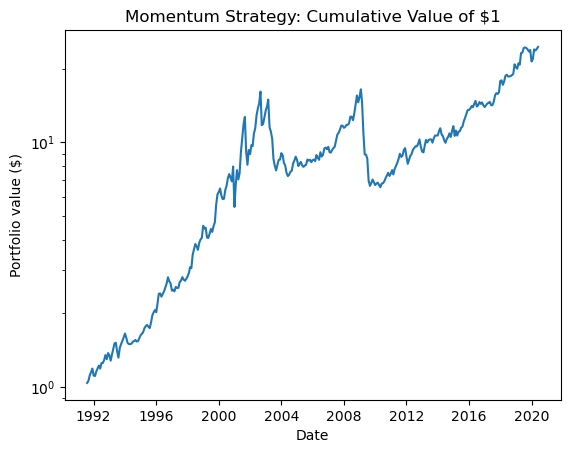

In [10]:
mom["cum_value"] = (1 + mom["mom_return"]).cumprod()

plt.figure()
plt.plot(mom.index, mom["cum_value"])
plt.yscale("log")  
plt.title("Momentum Strategy: Cumulative Value of $1")
plt.xlabel("Date")
plt.ylabel("Portfolio value ($)")
plt.show()


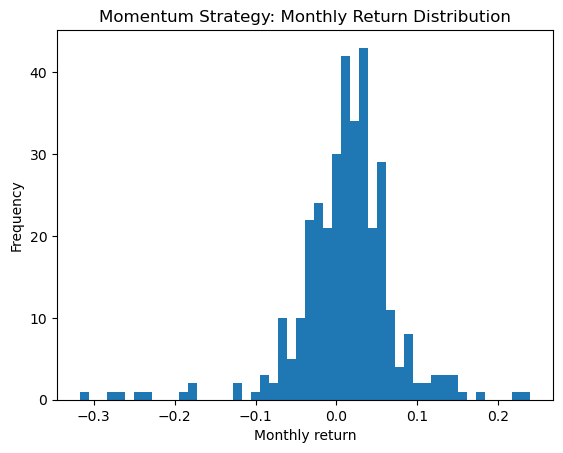

In [11]:
plt.figure()
plt.hist(mom["mom_return"], bins=50)
plt.title("Momentum Strategy: Monthly Return Distribution")
plt.xlabel("Monthly return")
plt.ylabel("Frequency")
plt.show()


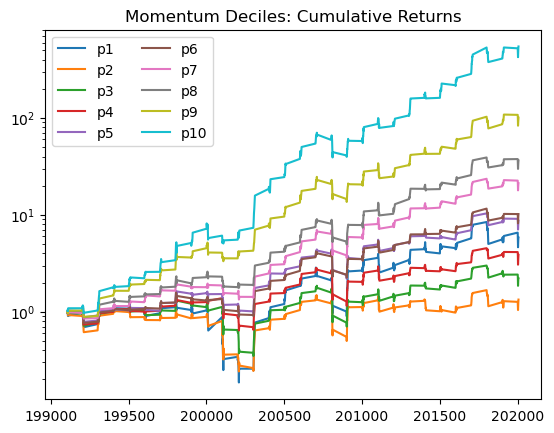

In [12]:
cum_deciles = (1 + decile_ret).cumprod()

plt.figure()
for i in range(1, 11):
    plt.plot(cum_deciles.index, cum_deciles[i], label=f"p{i}")

plt.yscale("log")
plt.title("Momentum Deciles: Cumulative Returns")
plt.legend(ncol=2)
plt.show()


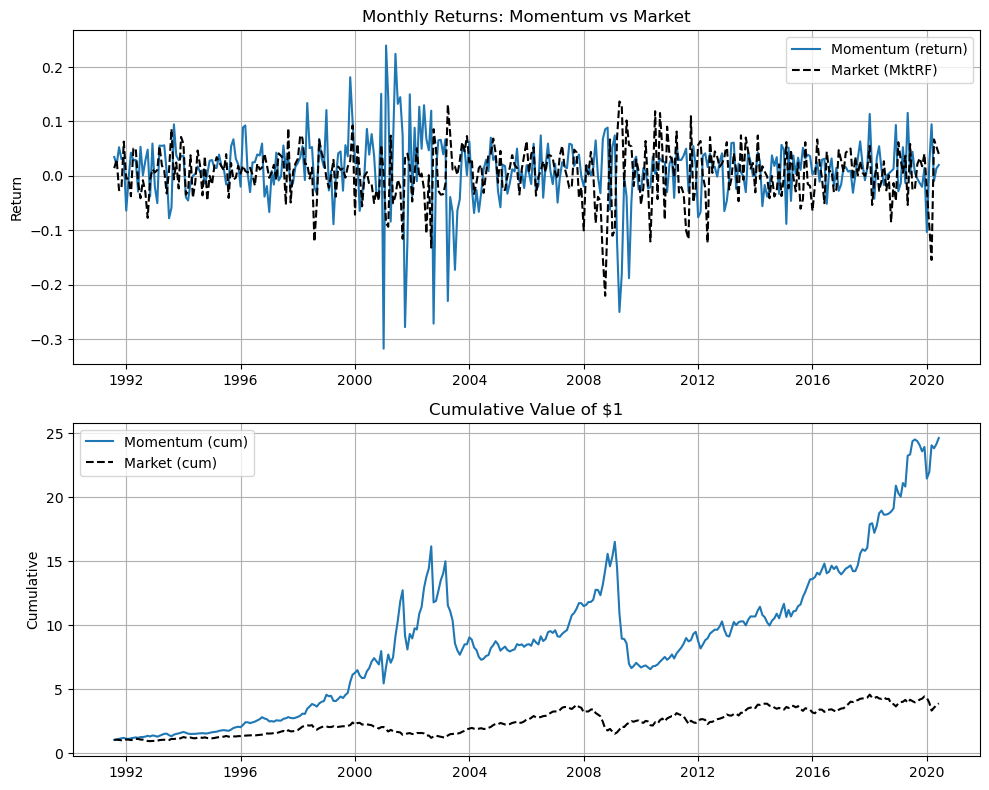

Saved plot to: outputs/momentum_vs_market.png


In [34]:
# ...existing code...
# plot momentum returns vs market returns (returns + cumulative)
mom_df = momentum.copy().reset_index()
if "mdate" in mom_df.columns:
    mom_df["date"] = pd.to_datetime(mom_df["mdate"].astype(str) + "01", format="%Y%m%d", errors="coerce")
else:
    col = next((c for c in mom_df.columns if "date" in c.lower() or "year" in c.lower() or "ym" in c.lower()), mom_df.columns[0])
    try:
        mom_df["date"] = pd.to_datetime(mom_df[col].astype(str), errors="coerce", format="%Y%m")
    except Exception:
        mom_df["date"] = pd.to_datetime(mom_df[col], errors="coerce")
mom_df = mom_df.sort_values("date").set_index("date")
mom_series = mom_df["mom_return"].astype(float).rename("momentum")

# market series from ff
ff_df = ff.copy()
date_col = next((c for c in ff_df.columns if "date" in c.lower() or "year" in c.lower() or "ym" in c.lower()), ff_df.columns[0])
try:
    ff_df["date"] = pd.to_datetime(ff_df[date_col].astype(str), errors="coerce", format="%Y%m")
except Exception:
    ff_df["date"] = pd.to_datetime(ff_df[date_col].astype(str), errors="coerce")
ff_df = ff_df.set_index("date", drop=True)
market_candidates = [c for c in ff_df.columns if any(k in c.lower() for k in ["mkt","market","mktrf","mkt-rf","rm","sp"])]
if not market_candidates:
    raise ValueError("No market column found in ff dataframe.")
market_col = market_candidates[0]
market_series = pd.to_numeric(ff_df[market_col], errors="coerce").rename("market")

# convert percents to decimals if needed
if mom_series.abs().median() > 1:
    mom_series = mom_series / 100.0
if market_series.abs().median() > 1:
    market_series = market_series / 100.0

# align
df_plot = pd.concat([mom_series, market_series], axis=1).sort_index().ffill().dropna(how="all").dropna()

# plot returns and cumulative
cum = (1 + df_plot).cumprod()

plt.figure(figsize=(10,8))
ax1 = plt.subplot(2,1,1)
ax1.plot(df_plot.index, df_plot["momentum"], label="Momentum (return)")
ax1.plot(df_plot.index, df_plot["market"], label=f"Market ({market_col})", linestyle="--", color="k")
ax1.set_title("Monthly Returns: Momentum vs Market")
ax1.set_ylabel("Return")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(2,1,2, sharex=ax1)
ax2.plot(cum.index, cum["momentum"], label="Momentum (cum)")
ax2.plot(cum.index, cum["market"], label="Market (cum)", linestyle="--", color="k")
ax2.set_title("Cumulative Value of $1")
ax2.set_ylabel("Cumulative")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
outpath = "outputs/momentum_vs_market.png"
plt.savefig(outpath, bbox_inches="tight", dpi=150)
plt.show()

print(f"Saved plot to: {outpath}")
# ...existing code...

In [13]:
# =========================
# VALUE STRATEGY (BEME)
# =========================

# 1) Ensure numeric types
monthly["RET"] = pd.to_numeric(monthly["RET"], errors="coerce")
monthly["ME"]  = pd.to_numeric(monthly["ME"],  errors="coerce")

annual["BEME"]  = pd.to_numeric(annual["BEME"], errors="coerce")
annual["fyear"] = pd.to_numeric(annual["fyear"], errors="coerce")

# 2) Lag BEME by one fiscal year (ex-ante)
annual = annual.sort_values(["ISIN", "fyear"]).copy()
annual["value_signal"] = annual.groupby("ISIN")["BEME"].shift(1)

# 3) Map annual signal to monthly data
monthly["year"] = monthly["mdate"] // 100

monthly = monthly.merge(
    annual[["ISIN", "fyear", "value_signal"]],
    left_on=["ISIN", "year"],
    right_on=["ISIN", "fyear"],
    how="left"
)

# 4) Top 50% market cap filter (each year)
monthly["top50_me"] = monthly.groupby("year")["ME"].transform(lambda x: x >= x.median())

# 5) Form value portfolios (quintiles) each year using lagged signal
monthly["value_quintile"] = np.nan
mask = monthly["top50_me"] & monthly["value_signal"].notna()

monthly.loc[mask, "value_quintile"] = (
    monthly.loc[mask]
    .groupby("year")["value_signal"]
    .transform(lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1)
)

# 6) Monthly equal-weighted returns per quintile
value_ret = (
    monthly.dropna(subset=["value_quintile"])
    .groupby(["mdate", "value_quintile"])["RET"]
    .mean()
    .unstack()
)

# 7) Long–short value strategy (High B/M - Low B/M)
value = (value_ret[5] - value_ret[1]).to_frame("value_return")

value.head()


,value_return
mdate,
199106,-0.010676
199107,0.050256
199108,-0.000458
199109,0.024512
199110,0.024058


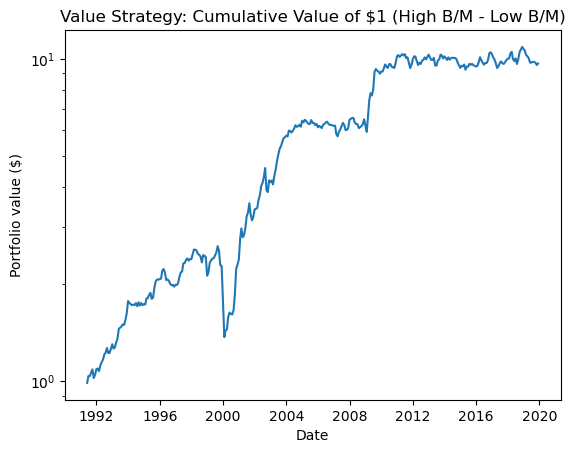

In [14]:
val = value.copy().reset_index()
val["date"] = pd.to_datetime(val["mdate"].astype(str) + "01", format="%Y%m%d")
val = val.sort_values("date").set_index("date")
val["cum_value"] = (1 + val["value_return"]).cumprod()

plt.figure()
plt.plot(val.index, val["cum_value"])
plt.yscale("log")  
plt.title("Value Strategy: Cumulative Value of $1 (High B/M - Low B/M)")
plt.xlabel("Date")
plt.ylabel("Portfolio value ($)")
plt.show()



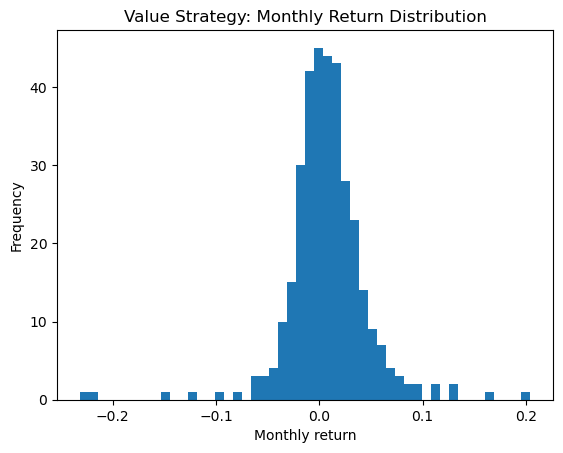

In [15]:
plt.figure()
plt.hist(val["value_return"].dropna(), bins=50)
plt.title("Value Strategy: Monthly Return Distribution")
plt.xlabel("Monthly return")
plt.ylabel("Frequency")
plt.show()


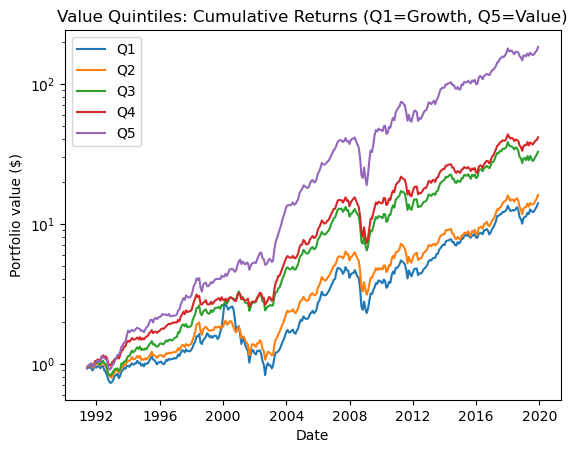

In [16]:
valq = value_ret.copy()
valq = valq.reset_index()
valq["date"] = pd.to_datetime(valq["mdate"].astype(str) + "01", format="%Y%m%d")
valq = valq.sort_values("date").set_index("date")
valq = valq.drop(columns=["mdate"])

cum_q = (1 + valq).cumprod()

plt.figure()
for q in cum_q.columns:
    plt.plot(cum_q.index, cum_q[q], label=f"Q{int(q)}")

plt.yscale("log")
plt.title("Value Quintiles: Cumulative Returns (Q1=Growth, Q5=Value)")
plt.xlabel("Date")
plt.ylabel("Portfolio value ($)")
plt.legend()
plt.show()


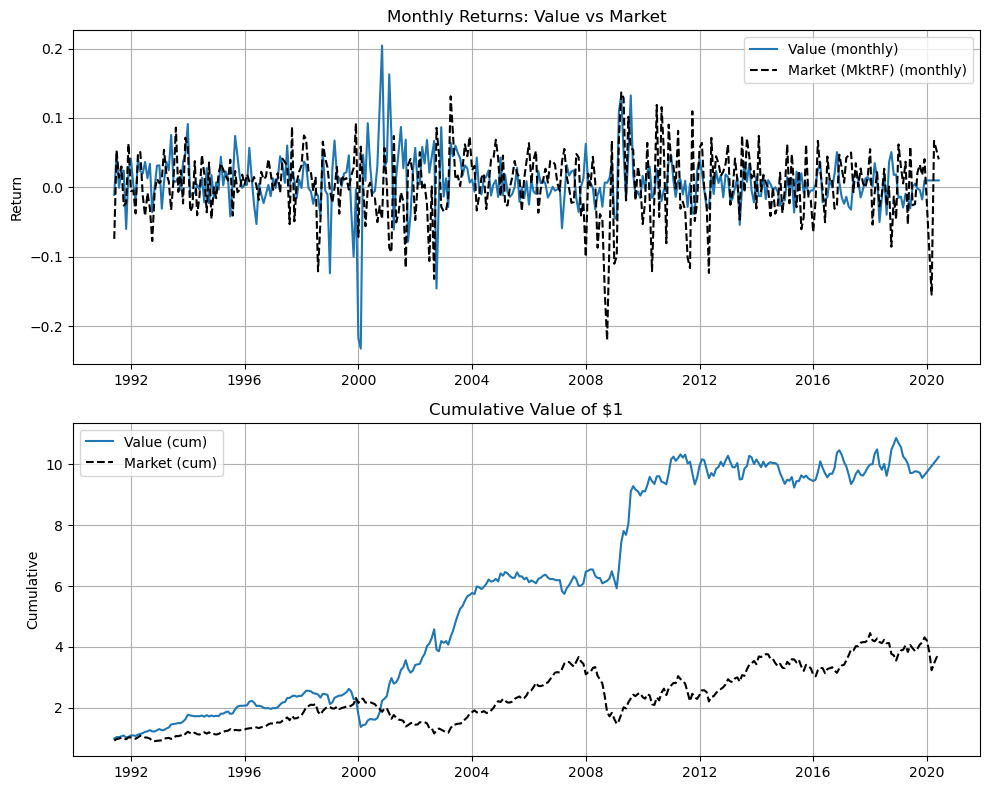

Saved plot to: outputs/value_vs_market.png


In [35]:
# ...existing code...
# prepare value series with datetime index (no repeated imports)
val_df = value.copy().reset_index()
if "mdate" in val_df.columns:
    val_df["date"] = pd.to_datetime(val_df["mdate"].astype(str) + "01", format="%Y%m%d", errors="coerce")
else:
    col = next((c for c in val_df.columns if "date" in c.lower() or "year" in c.lower() or "ym" in c.lower()), val_df.columns[0])
    try:
        val_df["date"] = pd.to_datetime(val_df[col].astype(str), errors="coerce", format="%Y%m")
    except Exception:
        val_df["date"] = pd.to_datetime(val_df[col], errors="coerce")
val_df = val_df.sort_values("date").set_index("date")
val_series = val_df["value_return"].astype(float).rename("value")

# prepare market series from ff (robust to common column names)
ff_df = ff.copy()
date_col = next((c for c in ff_df.columns if "date" in c.lower() or "year" in c.lower() or "ym" in c.lower()), ff_df.columns[0])
try:
    ff_df["date"] = pd.to_datetime(ff_df[date_col].astype(str), errors="coerce", format="%Y%m")
except Exception:
    ff_df["date"] = pd.to_datetime(ff_df[date_col].astype(str), errors="coerce")
ff_df = ff_df.set_index("date", drop=True)

market_candidates = [c for c in ff_df.columns if any(k in c.lower() for k in ["mkt","market","mktrf","mkt-rf","rm","sp"])]
if not market_candidates:
    raise ValueError("No market column found in ff dataframe.")
market_col = market_candidates[0]
market_series = pd.to_numeric(ff_df[market_col], errors="coerce").rename("market")

# convert percents to decimals if needed
if market_series.abs().median() > 1:
    market_series = market_series / 100.0
if val_series.abs().median() > 1:
    val_series = val_series / 100.0

# align series
series = pd.concat([val_series, market_series], axis=1).sort_index().ffill().dropna(how="all").dropna()

# monthly returns + cumulative comparison
cum = (1 + series).cumprod()

plt.figure(figsize=(10,8))
ax1 = plt.subplot(2,1,1)
ax1.plot(series.index, series["value"], label="Value (monthly)", color="C0")
ax1.plot(series.index, series["market"], label=f"Market ({market_col}) (monthly)", linestyle="--", color="k")
ax1.set_title("Monthly Returns: Value vs Market")
ax1.set_ylabel("Return")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(2,1,2, sharex=ax1)
ax2.plot(cum.index, cum["value"], label="Value (cum)", color="C0")
ax2.plot(cum.index, cum["market"], label="Market (cum)", linestyle="--", color="k")
ax2.set_title("Cumulative Value of $1")
ax2.set_ylabel("Cumulative")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
outpath = "outputs/value_vs_market.png"
plt.savefig(outpath, bbox_inches="tight", dpi=150)
plt.show()

print(f"Saved plot to: {outpath}")
# ...existing code...

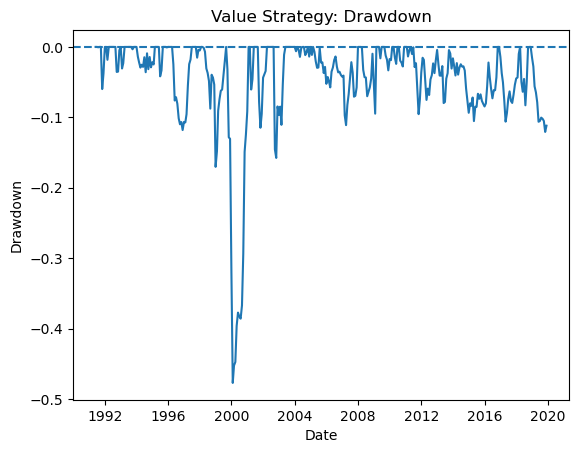

Maximum Drawdown: -0.4772893898053353


In [17]:
# =========================
# VALUE STRATEGY DRAWDOWN
# =========================

val = value.copy().reset_index()
val["date"] = pd.to_datetime(val["mdate"].astype(str) + "01", format="%Y%m%d")
val = val.sort_values("date").set_index("date")

# Cumulative value
val["cum_value"] = (1 + val["value_return"]).cumprod()

# Running peak
val["running_max"] = val["cum_value"].cummax()

# Drawdown
val["drawdown"] = val["cum_value"] / val["running_max"] - 1

# Plot drawdown
plt.figure()
plt.plot(val.index, val["drawdown"])
plt.axhline(0, linestyle="--")
plt.title("Value Strategy: Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

# Print maximum drawdown
print("Maximum Drawdown:", val["drawdown"].min())


combine value + momentum

In [18]:
strategies = momentum.join(value, how="inner")

strategies["fund_return"] = 0.5 * strategies["mom_return"] + 0.5 * strategies["value_return"]
vol_monthly = strategies["fund_return"].std()
vol_annual = vol_monthly * (12 ** 0.5)

print("Annualized Volatility:", vol_annual)


Annualized Volatility: 0.12601105653147632


In [19]:
cum = (1 + strategies["fund_return"]).cumprod()
running_max = cum.cummax()
drawdown = cum / running_max - 1

max_dd = drawdown.min()
print("Maximum Drawdown:", max_dd)


Maximum Drawdown: -0.24312999367823063


In [20]:
mean_monthly = strategies["fund_return"].mean()
sharpe = (mean_monthly / vol_monthly) * (12 ** 0.5)

print("Annualized Sharpe:", sharpe)


Annualized Sharpe: 0.8907043498112693


In [21]:
def annualized_vol(r):
    return r.std() * (12 ** 0.5)

def sharpe_ratio(r):
    return (r.mean() / r.std()) * (12 ** 0.5)


mom_vol  = annualized_vol(strategies["mom_return"])
val_vol  = annualized_vol(strategies["value_return"])
fund_vol = annualized_vol(strategies["fund_return"])

mom_sharpe  = sharpe_ratio(strategies["mom_return"])
val_sharpe  = sharpe_ratio(strategies["value_return"])
fund_sharpe = sharpe_ratio(strategies["fund_return"])


print("Momentum Vol:", mom_vol)
print("Value Vol:", val_vol)
print("Fund Vol:", fund_vol)

print("Momentum Sharpe:", mom_sharpe)
print("Value Sharpe:", val_sharpe)
print("Fund Sharpe:", fund_sharpe)


print("Momentum Sharpe:", sharpe_ratio(strategies["mom_return"]))
print("Value Sharpe:", sharpe_ratio(strategies["value_return"]))
print("Fund Sharpe:", sharpe_ratio(strategies["fund_return"]))


Momentum Vol: 0.2140579616097088
Value Vol: 0.1360837640540789
Fund Vol: 0.12601105653147632
Momentum Sharpe: 0.637242853558166
Value Sharpe: 0.6471770286702657
Fund Sharpe: 0.8907043498112693
Momentum Sharpe: 0.637242853558166
Value Sharpe: 0.6471770286702657
Fund Sharpe: 0.8907043498112693


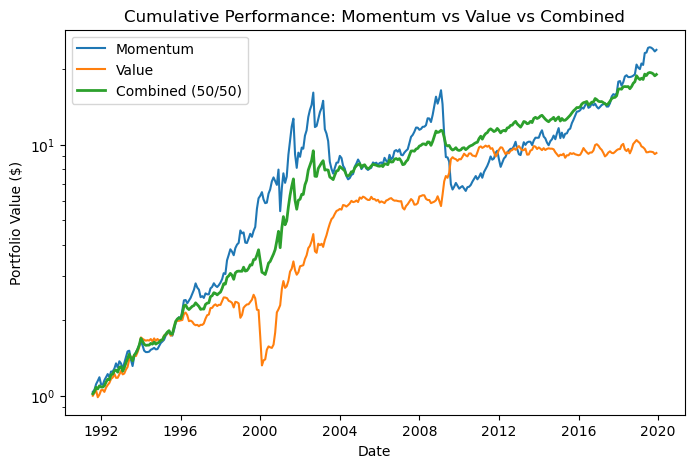

In [22]:
plotdf = strategies.reset_index()
plotdf["date"] = pd.to_datetime(plotdf["mdate"].astype(str) + "01", format="%Y%m%d")
plotdf = plotdf.sort_values("date").set_index("date")

cum = (1 + plotdf[["mom_return", "value_return", "fund_return"]]).cumprod()

plt.figure(figsize=(8,5))
plt.plot(cum.index, cum["mom_return"], label="Momentum")
plt.plot(cum.index, cum["value_return"], label="Value")
plt.plot(cum.index, cum["fund_return"], label="Combined (50/50)", linewidth=2)
plt.yscale("log")
plt.title("Cumulative Performance: Momentum vs Value vs Combined")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.show()


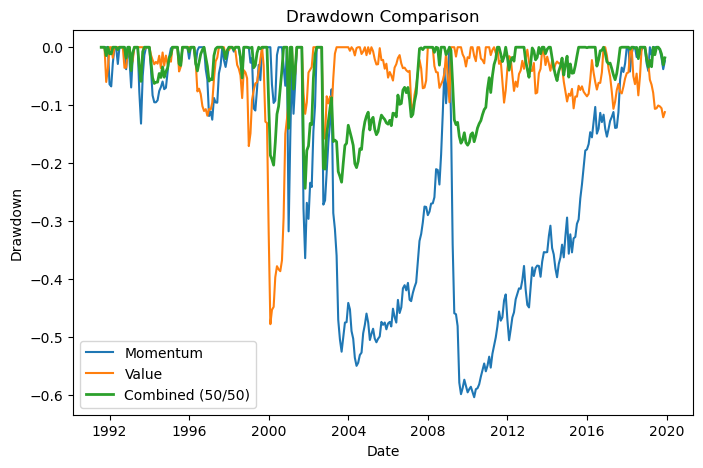

In [23]:
cum = (1 + plotdf[["mom_return", "value_return", "fund_return"]]).cumprod()
running_max = cum.cummax()
drawdown = cum / running_max - 1

plt.figure(figsize=(8,5))
plt.plot(drawdown.index, drawdown["mom_return"], label="Momentum")
plt.plot(drawdown.index, drawdown["value_return"], label="Value")
plt.plot(drawdown.index, drawdown["fund_return"], label="Combined (50/50)", linewidth=2)
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.show()


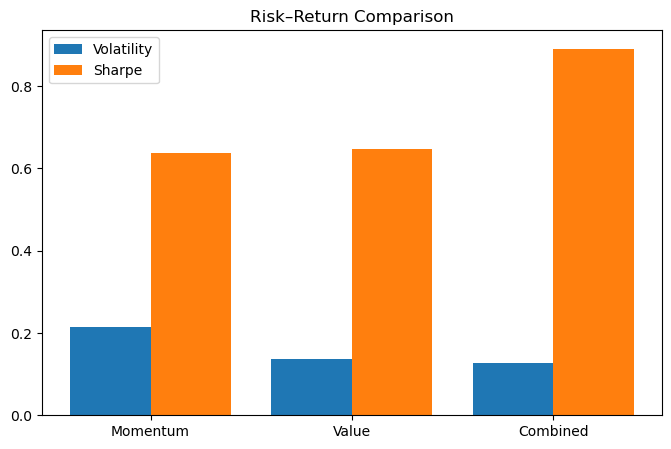

In [24]:
labels = ["Momentum", "Value", "Combined"]
vols = [mom_vol, val_vol, fund_vol]      # <-- use your computed numbers
sharpes = [mom_sharpe, val_sharpe, fund_sharpe]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, vols, width=0.4, label="Volatility")
plt.bar(x + 0.2, sharpes, width=0.4, label="Sharpe")

plt.xticks(x, labels)
plt.title("Risk–Return Comparison")
plt.legend()
plt.show()


In [25]:
# =========================
# VOLATILITY TARGETING
# =========================


window = 20
target_vol = 0.10  

strategies["mom_vol"] = strategies["mom_return"].rolling(window).std() * (12 ** 0.5)
strategies["val_vol"] = strategies["value_return"].rolling(window).std() * (12 ** 0.5)
strategies["fund_vol"] = strategies["fund_return"].rolling(window).std() * (12 ** 0.5)


strategies["leverage"] = target_vol / strategies["fund_vol"]
strategies["leverage"] = strategies["leverage"].fillna(1.0) 
strategies["leverage"] = strategies["leverage"].clip(0.1, 3.0)  


strategies["vt_return"] = strategies["fund_return"] * strategies["leverage"]


vt_vol = annualized_vol(strategies["vt_return"])
vt_sharpe = sharpe_ratio(strategies["vt_return"])

print("=== Volatility Targeting Results ===")
print(f"Target Volatility: {target_vol:.2%}")
print(f"Original Combined Vol: {fund_vol:.2%}")
print(f"VT-adjusted Vol: {vt_vol:.2%}")
print(f"Original Combined Sharpe: {fund_sharpe:.4f}")
print(f"VT-adjusted Sharpe: {vt_sharpe:.4f}")
print(f"Average Leverage: {strategies['leverage'].mean():.2f}")


=== Volatility Targeting Results ===
Target Volatility: 10.00%
Original Combined Vol: 12.60%
VT-adjusted Vol: 10.13%
Original Combined Sharpe: 0.8907
VT-adjusted Sharpe: 1.1677
Average Leverage: 1.21


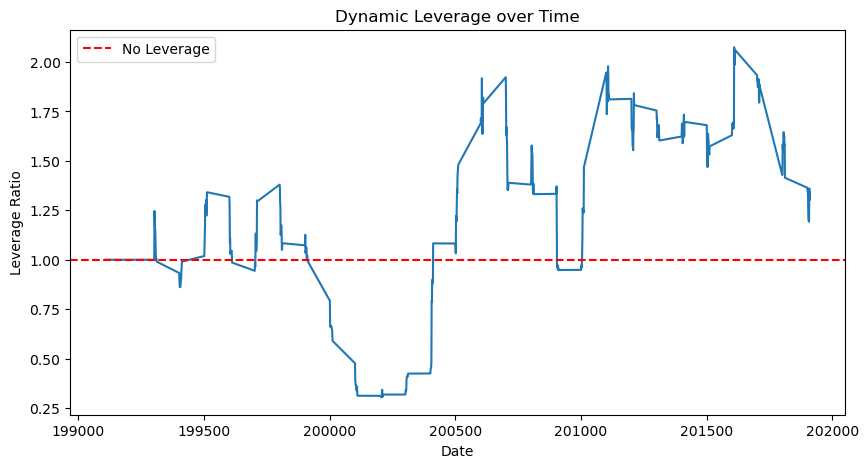

In [26]:

plt.figure(figsize=(10,5))
plt.plot(strategies.index, strategies["leverage"])
plt.title("Dynamic Leverage over Time")
plt.xlabel("Date")
plt.ylabel("Leverage Ratio")
plt.axhline(y=1.0, linestyle="--", color="red", label="No Leverage")
plt.legend()
plt.show()


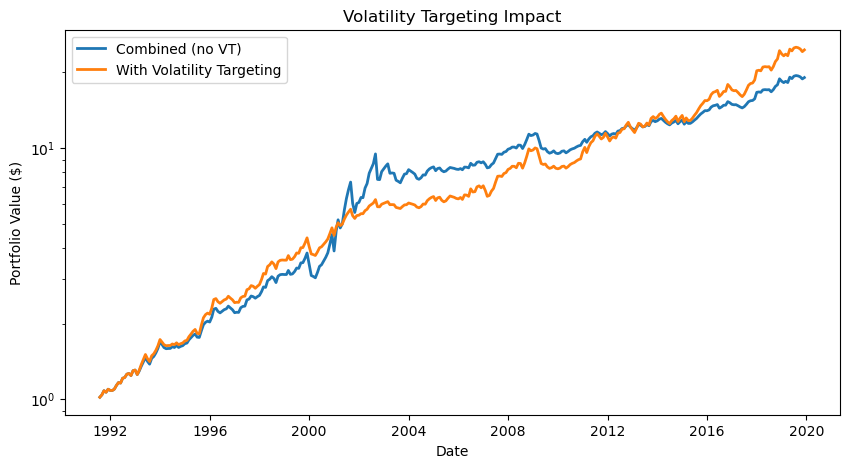

In [27]:

plotdf_vt = strategies.reset_index()
plotdf_vt["date"] = pd.to_datetime(plotdf_vt["mdate"].astype(str) + "01", format="%Y%m%d")
plotdf_vt = plotdf_vt.sort_values("date").set_index("date")

cum_vt = (1 + plotdf_vt[["fund_return", "vt_return"]]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cum_vt.index, cum_vt["fund_return"], label="Combined (no VT)", linewidth=2)
plt.plot(cum_vt.index, cum_vt["vt_return"], label="With Volatility Targeting", linewidth=2)
plt.yscale("log")
plt.title("Volatility Targeting Impact")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.show()


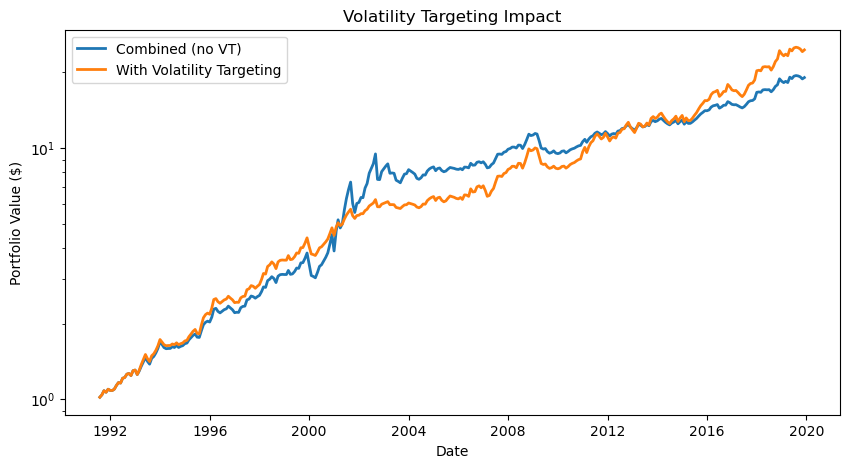

In [28]:

plotdf_vt = strategies.reset_index()
plotdf_vt["date"] = pd.to_datetime(plotdf_vt["mdate"].astype(str) + "01", format="%Y%m%d")
plotdf_vt = plotdf_vt.sort_values("date").set_index("date")

cum_vt = (1 + plotdf_vt[["fund_return", "vt_return"]]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cum_vt.index, cum_vt["fund_return"], label="Combined (no VT)", linewidth=2)
plt.plot(cum_vt.index, cum_vt["vt_return"], label="With Volatility Targeting", linewidth=2)
plt.yscale("log")
plt.title("Volatility Targeting Impact")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.show()


In [29]:
# =========================
# PERFORMANCE COMPARISON: Original vs Volatility Targeting
# =========================

# Calculate drawdowns for original and VT portfolios
plotdf_compare = strategies.reset_index()
plotdf_compare["date"] = pd.to_datetime(plotdf_compare["mdate"].astype(str) + "01", format="%Y%m%d")
plotdf_compare = plotdf_compare.sort_values("date").set_index("date")

# Original portfolio
cum_fund = (1 + plotdf_compare["fund_return"]).cumprod()
running_max_fund = cum_fund.cummax()
dd_fund = cum_fund / running_max_fund - 1
max_dd_fund = dd_fund.min()

# VT-adjusted portfolio
cum_vt = (1 + plotdf_compare["vt_return"]).cumprod()
running_max_vt = cum_vt.cummax()
dd_vt = cum_vt / running_max_vt - 1
max_dd_vt = dd_vt.min()

print(f"Original Combined - Max Drawdown: {max_dd_fund:.2%}")
print(f"With Vol Targeting - Max Drawdown: {max_dd_vt:.2%}")


Original Combined - Max Drawdown: -24.31%
With Vol Targeting - Max Drawdown: -17.41%


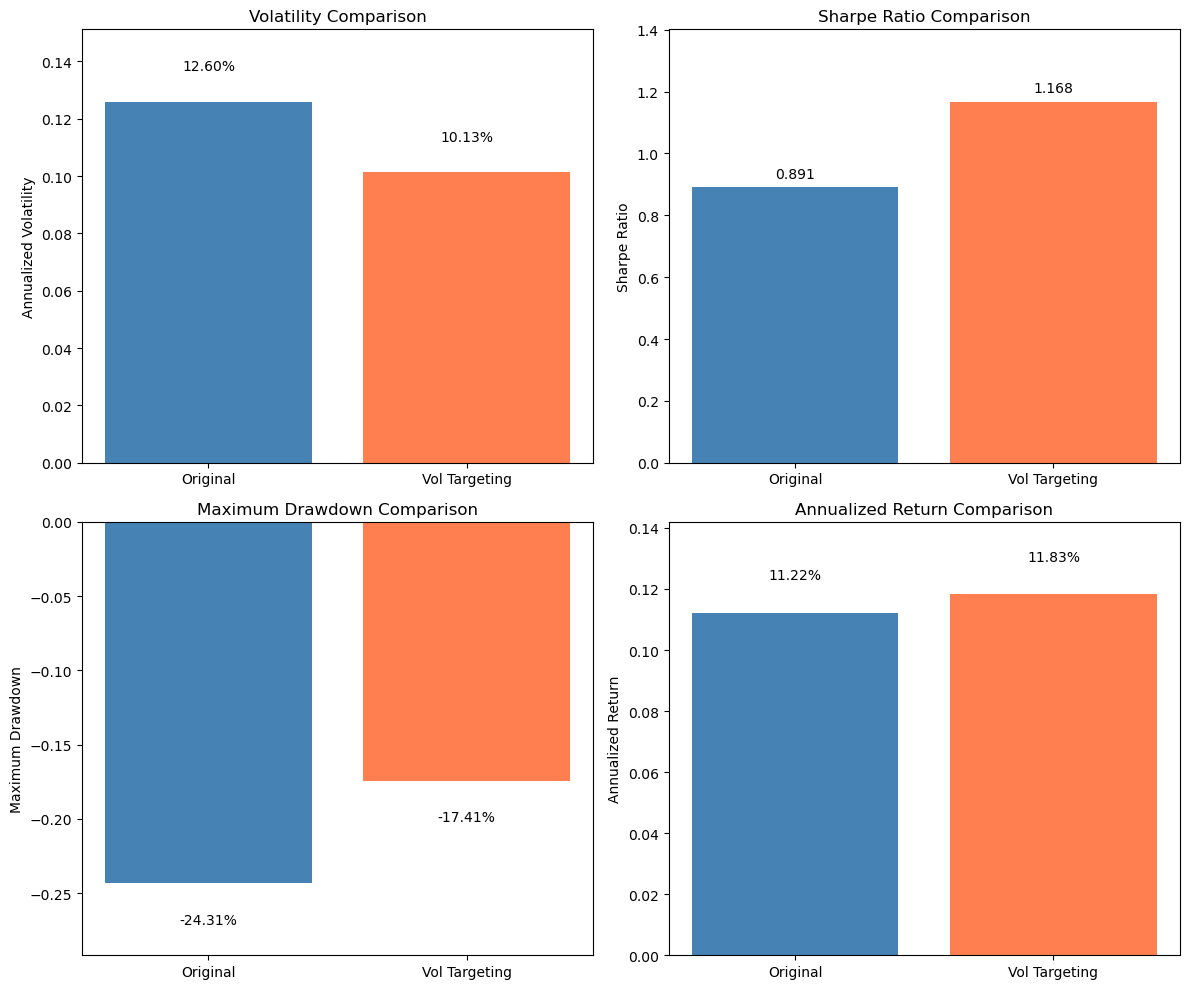

In [30]:
# Create performance comparison bar charts
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Volatility comparison
ax = axes[0, 0]
metrics = ["Original", "Vol Targeting"]
vols = [fund_vol, vt_vol]
ax.bar(metrics, vols, color=["steelblue", "coral"])
ax.set_ylabel("Annualized Volatility")
ax.set_title("Volatility Comparison")
ax.set_ylim(0, max(vols) * 1.2)
for i, v in enumerate(vols):
    ax.text(i, v + 0.01, f"{v:.2%}", ha="center", va="bottom")

# Sharpe ratio comparison
ax = axes[0, 1]
sharpes = [fund_sharpe, vt_sharpe]
ax.bar(metrics, sharpes, color=["steelblue", "coral"])
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Sharpe Ratio Comparison")
ax.set_ylim(0, max(sharpes) * 1.2)
for i, v in enumerate(sharpes):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom")

# Maximum drawdown comparison
ax = axes[1, 0]
drawdowns = [max_dd_fund, max_dd_vt]
ax.bar(metrics, drawdowns, color=["steelblue", "coral"])
ax.set_ylabel("Maximum Drawdown")
ax.set_title("Maximum Drawdown Comparison")
ax.set_ylim(min(drawdowns) * 1.2, 0)
for i, v in enumerate(drawdowns):
    ax.text(i, v - 0.02, f"{v:.2%}", ha="center", va="top")

# Annualized return comparison
ax = axes[1, 1]
returns = [
    strategies["fund_return"].mean() * 12,
    strategies["vt_return"].mean() * 12
]
ax.bar(metrics, returns, color=["steelblue", "coral"])
ax.set_ylabel("Annualized Return")
ax.set_title("Annualized Return Comparison")
ax.set_ylim(0, max(returns) * 1.2)
for i, v in enumerate(returns):
    ax.text(i, v + 0.01, f"{v:.2%}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


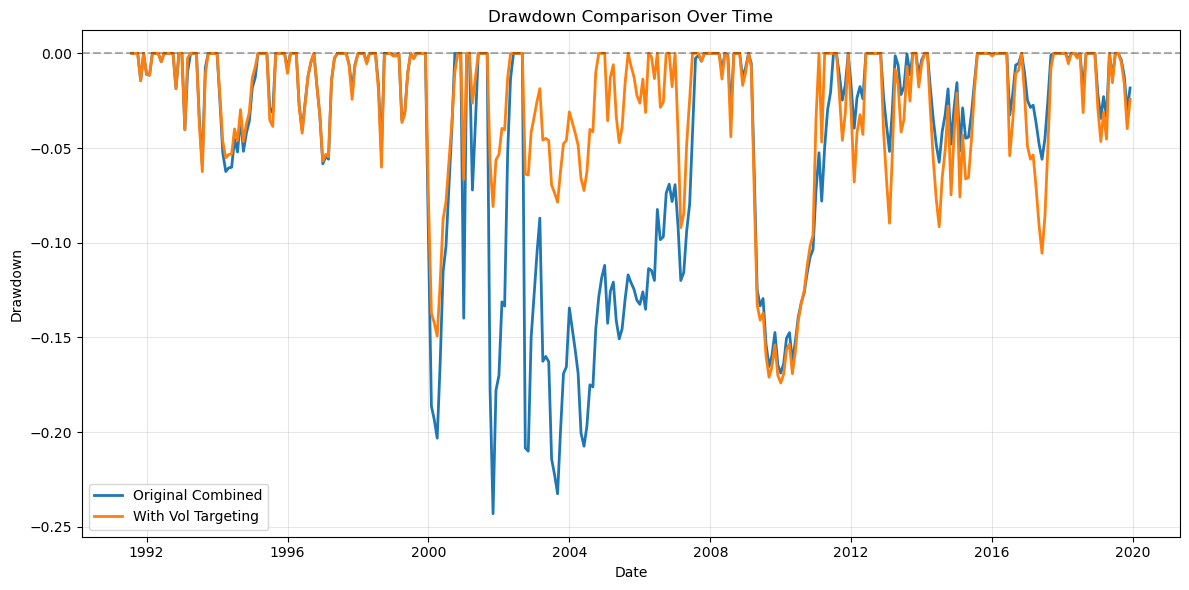


=== DRAWDOWN SUMMARY ===
Original Combined - Max Drawdown: -24.31%
With Vol Targeting - Max Drawdown: -17.41%
Improvement: -6.90%


In [31]:
# Plot drawdown time series comparison
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plotdf_compare.index, dd_fund, label="Original Combined", linewidth=2)
ax.plot(plotdf_compare.index, dd_vt, label="With Vol Targeting", linewidth=2)
ax.axhline(y=0, linestyle="--", color="black", alpha=0.3)
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.set_title("Drawdown Comparison Over Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n=== DRAWDOWN SUMMARY ===")
print(f"Original Combined - Max Drawdown: {max_dd_fund:.2%}")
print(f"With Vol Targeting - Max Drawdown: {max_dd_vt:.2%}")
print(f"Improvement: {max_dd_fund - max_dd_vt:.2%}")


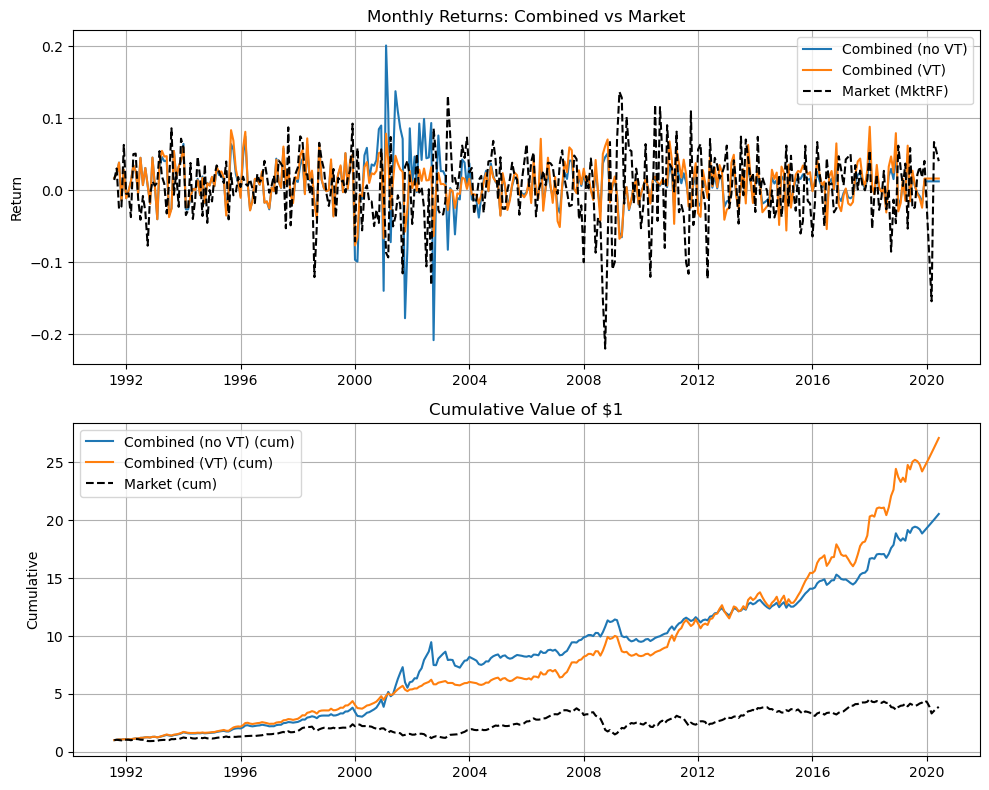

Saved plot to: outputs/combined_vs_market.png


In [37]:
# ...existing code...
# Compare combined (no VT) and combined (with VT) vs market — monthly returns + cumulative wealth
df = strategies.copy().reset_index()

# build date column
if "mdate" in df.columns:
    df["date"] = pd.to_datetime(df["mdate"].astype(str) + "01", format="%Y%m%d", errors="coerce")
else:
    col = next((c for c in df.columns if "date" in c.lower() or "year" in c.lower() or "ym" in c.lower()), df.columns[0])
    try:
        df["date"] = pd.to_datetime(df[col].astype(str), format="%Y%m", errors="coerce")
    except Exception:
        df["date"] = pd.to_datetime(df[col], errors="coerce")

df = df.sort_values("date").set_index("date")

# ensure required series exist
for col in ["fund_return", "vt_return"]:
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}")

comb_series = df[["fund_return", "vt_return"]].rename(columns={"fund_return":"combined_no_vt","vt_return":"combined_vt"})

# market series from ff (reuse existing ff)
ff_df = ff.copy()
date_col = next((c for c in ff_df.columns if "date" in c.lower() or "year" in c.lower() or "ym" in c.lower()), ff_df.columns[0])
try:
    ff_df["date"] = pd.to_datetime(ff_df[date_col].astype(str), format="%Y%m", errors="coerce")
except Exception:
    ff_df["date"] = pd.to_datetime(ff_df[date_col].astype(str), errors="coerce")
ff_df = ff_df.set_index("date", drop=True)
market_candidates = [c for c in ff_df.columns if any(k in c.lower() for k in ["mkt","market","mktrf","mkt-rf","rm","sp"])]
if not market_candidates:
    raise ValueError("No market column found in ff dataframe.")
market_col = market_candidates[0]
market_series = pd.to_numeric(ff_df[market_col], errors="coerce").rename("market")

# convert percents to decimals if needed
if comb_series.abs().median().max() > 1:
    comb_series = comb_series / 100.0
if market_series.abs().median() > 1:
    market_series = market_series / 100.0

# align and drop missing
plot_df = pd.concat([comb_series, market_series], axis=1).sort_index().ffill().dropna(how="all").dropna()

# monthly returns + cumulative wealth
cum = (1 + plot_df).cumprod()

plt.figure(figsize=(10,8))
ax1 = plt.subplot(2,1,1)
ax1.plot(plot_df.index, plot_df["combined_no_vt"], label="Combined (no VT)")
ax1.plot(plot_df.index, plot_df["combined_vt"], label="Combined (VT)")
ax1.plot(plot_df.index, plot_df["market"], label=f"Market ({market_col})", linestyle="--", color="k")
ax1.set_title("Monthly Returns: Combined vs Market")
ax1.set_ylabel("Return")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(2,1,2, sharex=ax1)
ax2.plot(cum.index, cum["combined_no_vt"], label="Combined (no VT) (cum)")
ax2.plot(cum.index, cum["combined_vt"], label="Combined (VT) (cum)")
ax2.plot(cum.index, cum["market"], label="Market (cum)", linestyle="--", color="k")
ax2.set_title("Cumulative Value of $1")
ax2.set_ylabel("Cumulative")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
outpath = "outputs/combined_vs_market.png"
plt.savefig(outpath, bbox_inches="tight", dpi=150)
plt.show()

print(f"Saved plot to: {outpath}")
# ...existing code...

In [38]:
# python
# 诊断 market series
market_col = market_col  # 如果在当前 scope 有值，否则替换为你用的列名字符串
s = ff[market_col].copy()
print("market_col:", market_col)
print("head:", s.head(8).to_list())
print("dtype:", s.dtype)
print("count, nulls:", s.count(), s.isna().sum())
print("median, mean:", s.median(), s.mean())

# 检查是否为百分比（大多数值 > 1 表示百分比）
print("median_abs >1 ?", s.abs().median() > 1)

# 如果有 RF 列且 market 是 Mkt-RF，建议合成总市场：
if "Mkt-RF" in ff.columns or "mkt-rf" in [c.lower() for c in ff.columns]:
    rf_col = next((c for c in ff.columns if c.lower() in ["rf","riskfree","risk-free","r_f"]), None)
    print("found RF column:", rf_col)
    if rf_col:
        mkt_total = pd.to_numeric(ff[market_col], errors="coerce") + pd.to_numeric(ff[rf_col], errors="coerce")
        print("sample total market (Mkt-RF + RF):", mkt_total.dropna().head().to_list())

# 计算年化收益和最终财富（假设 monthly）
s_num = pd.to_numeric(s, errors="coerce").dropna()
if s_num.abs().median() > 1:
    s_num = s_num / 100.0
cum = (1 + s_num).cumprod()
print("n months:", len(s_num))
if len(s_num)>0:
    final = cum.iloc[-1]
    ann = (final ** (12/len(s_num))) - 1
    print("final wealth from $1:", final)
    print("annualized return:", ann)
print("nonzero fraction:", (s_num!=0).mean())

market_col: MktRF
head: [-0.0741, 0.053, 0.0142, 0.0302, -0.0262, -0.0227, 0.063, -0.0052]
dtype: float64
count, nulls: 349 0
median, mean: 0.0077 0.0050255014326647555
median_abs >1 ? False
n months: 349
final wealth from $1: 3.7869862246143025
annualized return: 0.046848957617959375
nonzero fraction: 1.0
